# SolarScan — 04b · CNN amélioré (modèle performant)

Le notebook 04 a donné un macro-F1 de **0.487**, mais avec une courbe instable et une sur-prédiction des classes rares. Ici on applique un *recipe* d'entraînement sérieux. **Chaque amélioration corrige un problème observé :**

1. **Transfer learning en 2 phases** — on entraîne d'abord la nouvelle tête (backbone gelé), puis on fine-tune tout. Évite que la tête aléatoire détruise les features pré-entraînées.
2. **LR plus bas (1e-4) + cosine scheduler** — corrige l'instabilité de la courbe.
3. **AdamW + weight decay** — régularisation contre le surapprentissage.
4. **Pondération adoucie (√) + label smoothing** — corrige la sur-prédiction des classes rares (meilleur équilibre précision/rappel).
5. **Augmentation renforcée + early stopping** sur le macro-F1 de validation.

> ⚡ À lancer sur **Colab GPU** (Runtime → GPU → Run all). Durée ~20-30 min.

## 0. Setup (dépendances + données)

In [1]:
%pip install -q torch torchvision scikit-learn pandas pillow matplotlib

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device :', device)

Device : cuda


In [3]:
DATA_DIR = Path('data') if Path('data').exists() else Path('../data')
SPLITS = Path('splits') if Path('splits').exists() else Path('../splits')

if not (DATA_DIR / 'module_metadata.json').exists():
    import urllib.request, zipfile, shutil
    print('Telechargement du dataset...')
    url = 'https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip'
    urllib.request.urlretrieve(url, 'solar.zip')
    with zipfile.ZipFile('solar.zip') as z:
        z.extractall('tmp')
    shutil.move('tmp/InfraredSolarModules', 'data')
    DATA_DIR = Path('data')

if not (SPLITS / 'train.csv').exists():
    from sklearn.model_selection import train_test_split
    with open(DATA_DIR / 'module_metadata.json', encoding='utf-8') as f:
        meta = json.load(f)
    data = pd.DataFrame([{'filepath': v['image_filepath'], 'classe': v['anomaly_class']}
                         for v in meta.values()])
    tr, tmp = train_test_split(data, test_size=0.30, stratify=data['classe'], random_state=42)
    va, te = train_test_split(tmp, test_size=0.50, stratify=tmp['classe'], random_state=42)
    SPLITS = Path('splits'); SPLITS.mkdir(exist_ok=True)
    tr.to_csv(SPLITS / 'train.csv', index=False)
    va.to_csv(SPLITS / 'val.csv', index=False)
    te.to_csv(SPLITS / 'test.csv', index=False)

print('DATA_DIR =', DATA_DIR.resolve())

Telechargement du dataset...
DATA_DIR = /content/data


## 1. Dataset & augmentation renforcée

Plus de variété sur le train (flips, rotation, translation) → le modèle généralise mieux et surapprend moins.

In [4]:
CLASSES = sorted(pd.read_csv(SPLITS / 'train.csv')['classe'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class SolarDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(DATA_DIR / row['filepath'])
        return self.transform(img), CLASS_TO_IDX[row['classe']]

train_dl = DataLoader(SolarDataset(SPLITS / 'train.csv', train_tf), batch_size=64, shuffle=True, num_workers=2)
val_dl = DataLoader(SolarDataset(SPLITS / 'val.csv', eval_tf), batch_size=64, shuffle=False, num_workers=2)
test_dl = DataLoader(SolarDataset(SPLITS / 'test.csv', eval_tf), batch_size=64, shuffle=False, num_workers=2)
n_train = len(train_dl.dataset)
print('train/val/test :', n_train, len(val_dl.dataset), len(test_dl.dataset))

train/val/test : 14000 3000 3000


## 2. Modèle

ResNet-18 pré-entraîné. *(Tu peux tester `resnet34` pour un modèle plus profond — change juste la ligne.)*

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 88.6MB/s]


## 3. Perte adoucie + label smoothing

Au lieu des poids `balanced` bruts (qui faisaient sur-prédire les rares), on prend leur **racine carrée** : on corrige le déséquilibre mais plus en douceur. Le **label smoothing (0.1)** évite que le modèle soit trop sûr de lui → meilleure généralisation.

In [6]:
y_train = pd.read_csv(SPLITS / 'train.csv')['classe'].map(CLASS_TO_IDX).values
w = compute_class_weight('balanced', classes=np.arange(len(CLASSES)), y=y_train)
w = np.sqrt(w)            # adoucir
w = w / w.mean()         # recentrer autour de 1
class_weights = torch.tensor(w, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
print('Poids (adoucis) :', np.round(w, 2))

Poids (adoucis) : [0.57 0.69 0.81 0.64 1.88 1.58 1.59 0.25 0.87 0.77 1.74 0.61]


## 4. Fonctions d'entraînement & d'évaluation

`train()` fait train + validation à chaque epoch, garde le **meilleur** modèle (selon le macro-F1 de val) et s'arrête tôt si ça ne progresse plus (**early stopping**).

In [7]:
def macro_f1(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            preds += model(x.to(device)).argmax(1).cpu().tolist()
            gts += y.tolist()
    return f1_score(gts, preds, average='macro'), preds, gts

def train(model, criterion, optimizer, scheduler, epochs, patience=5, tag='phase'):
    best_f1, best_state, wait = 0.0, None, 0
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if scheduler is not None:
            scheduler.step()
        val_f1, _, _ = macro_f1(model, val_dl)
        print(f'[{tag}] epoch {epoch+1}/{epochs} - loss {running/n_train:.3f} - val macro-F1 {val_f1:.3f}')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('  -> early stopping')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_f1

## 5. Phase 1 — entraîner la tête (backbone gelé)

On gèle tout sauf la dernière couche. La tête (initialisée au hasard) apprend à utiliser les features pré-entraînées **sans les abîmer**.

In [8]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

opt1 = torch.optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
train(model, criterion, opt1, None, epochs=4, patience=4, tag='tete')

[tete] epoch 1/4 - loss 2.517 - val macro-F1 0.214
[tete] epoch 2/4 - loss 2.392 - val macro-F1 0.239
[tete] epoch 3/4 - loss 2.343 - val macro-F1 0.235
[tete] epoch 4/4 - loss 2.316 - val macro-F1 0.263


0.2629566832941694

## 6. Phase 2 — fine-tuning complet (LR bas + cosine)

On dégèle tout et on ajuste finement **l'ensemble** du réseau, avec un LR faible (1e-4) qui décroît en cosinus. C'est là que le gros du gain arrive.

In [9]:
for p in model.parameters():
    p.requires_grad = True

EPOCHS2 = 15
opt2 = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS2)
best = train(model, criterion, opt2, sched, epochs=EPOCHS2, patience=5, tag='fine-tune')

torch.save(model.state_dict(), 'best_model_v2.pt')
print('Meilleur val macro-F1 :', round(best, 3))

[fine-tune] epoch 1/15 - loss 2.028 - val macro-F1 0.475
[fine-tune] epoch 2/15 - loss 1.808 - val macro-F1 0.538
[fine-tune] epoch 3/15 - loss 1.710 - val macro-F1 0.556
[fine-tune] epoch 4/15 - loss 1.639 - val macro-F1 0.573
[fine-tune] epoch 5/15 - loss 1.587 - val macro-F1 0.634
[fine-tune] epoch 6/15 - loss 1.546 - val macro-F1 0.652
[fine-tune] epoch 7/15 - loss 1.506 - val macro-F1 0.641
[fine-tune] epoch 8/15 - loss 1.469 - val macro-F1 0.652
[fine-tune] epoch 9/15 - loss 1.430 - val macro-F1 0.686
[fine-tune] epoch 10/15 - loss 1.407 - val macro-F1 0.677
[fine-tune] epoch 11/15 - loss 1.376 - val macro-F1 0.679
[fine-tune] epoch 12/15 - loss 1.343 - val macro-F1 0.686
[fine-tune] epoch 13/15 - loss 1.333 - val macro-F1 0.697
[fine-tune] epoch 14/15 - loss 1.315 - val macro-F1 0.700
[fine-tune] epoch 15/15 - loss 1.306 - val macro-F1 0.694
Meilleur val macro-F1 : 0.7


## 7. Évaluation finale sur le test

In [10]:
_, preds, gts = macro_f1(model, test_dl)
print('Test accuracy :', round(accuracy_score(gts, preds), 3))
print('Test macro-F1 :', round(f1_score(gts, preds, average='macro'), 3))
print()
print(classification_report(gts, preds, target_names=CLASSES))

Test accuracy : 0.803
Test macro-F1 : 0.653

                precision    recall  f1-score   support

          Cell       0.72      0.70      0.71       281
    Cell-Multi       0.54      0.45      0.49       193
      Cracking       0.70      0.74      0.72       141
         Diode       0.96      0.96      0.96       225
   Diode-Multi       0.74      0.96      0.83        26
      Hot-Spot       0.38      0.54      0.44        37
Hot-Spot-Multi       0.36      0.51      0.42        37
    No-Anomaly       0.95      0.90      0.92      1500
Offline-Module       0.54      0.62      0.58       124
     Shadowing       0.68      0.77      0.72       159
       Soiling       0.32      0.35      0.34        31
    Vegetation       0.67      0.73      0.70       246

      accuracy                           0.80      3000
     macro avg       0.63      0.69      0.65      3000
  weighted avg       0.81      0.80      0.81      3000



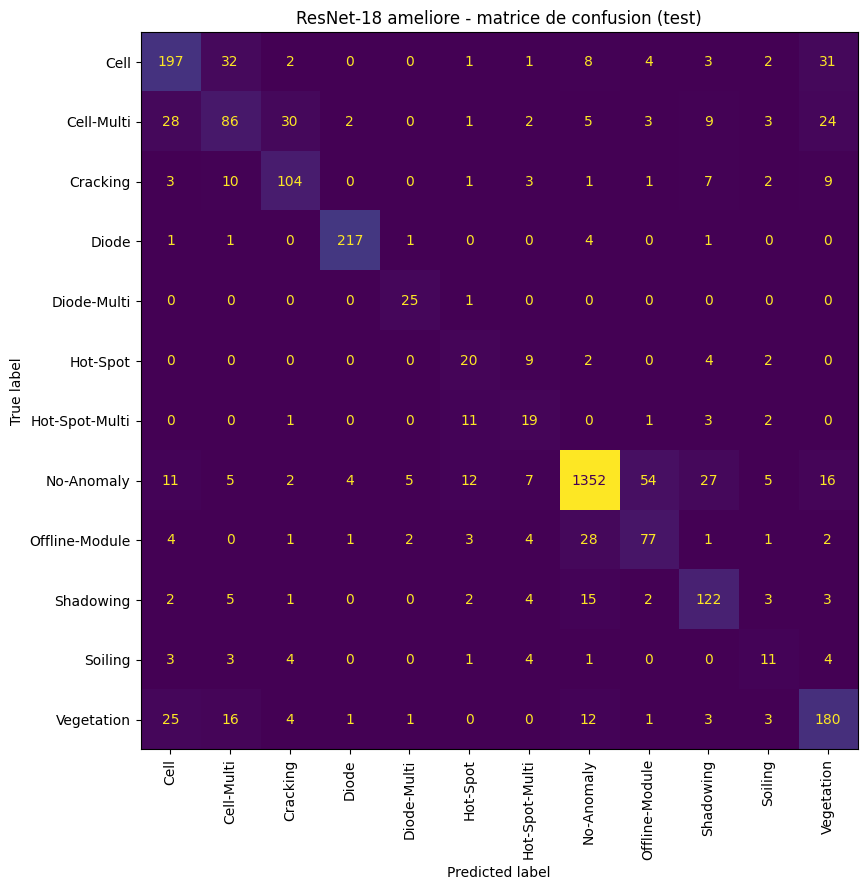

In [11]:
cm = confusion_matrix(gts, preds)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, xticks_rotation=90, colorbar=False)
plt.title('ResNet-18 ameliore - matrice de confusion (test)')
plt.tight_layout()
plt.show()

## 8. Bilan

| Modèle | Macro-F1 (test) |
|---|---|
| Dummy | ~0.06 |
| Random Forest | _notebook 03_ |
| ResNet-18 (04) | 0.487 |
| **ResNet-18 amélioré (04b)** | **_ce notebook_** |

Compare aussi le **rapport par classe** au 04 : la précision des classes rares devrait s'être améliorée (moins de fausses alertes), et No-Anomaly devrait avoir un meilleur rappel.

**Si tu veux pousser encore :** `resnet34`, plus d'epochs, ou tester une *focal loss*.

➡️ Une fois le score obtenu, on le reporte dans le **README + CV**, puis notebook 05 : **Grad-CAM** (voir où le modèle regarde).